figure7的源代码找不到了，为了导出eps格式的图片，重新根据源数据画图

## Figure 7 复现

以下数据逐项取自原图柱顶标注；代码同时导出 PNG 和 EPS。

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


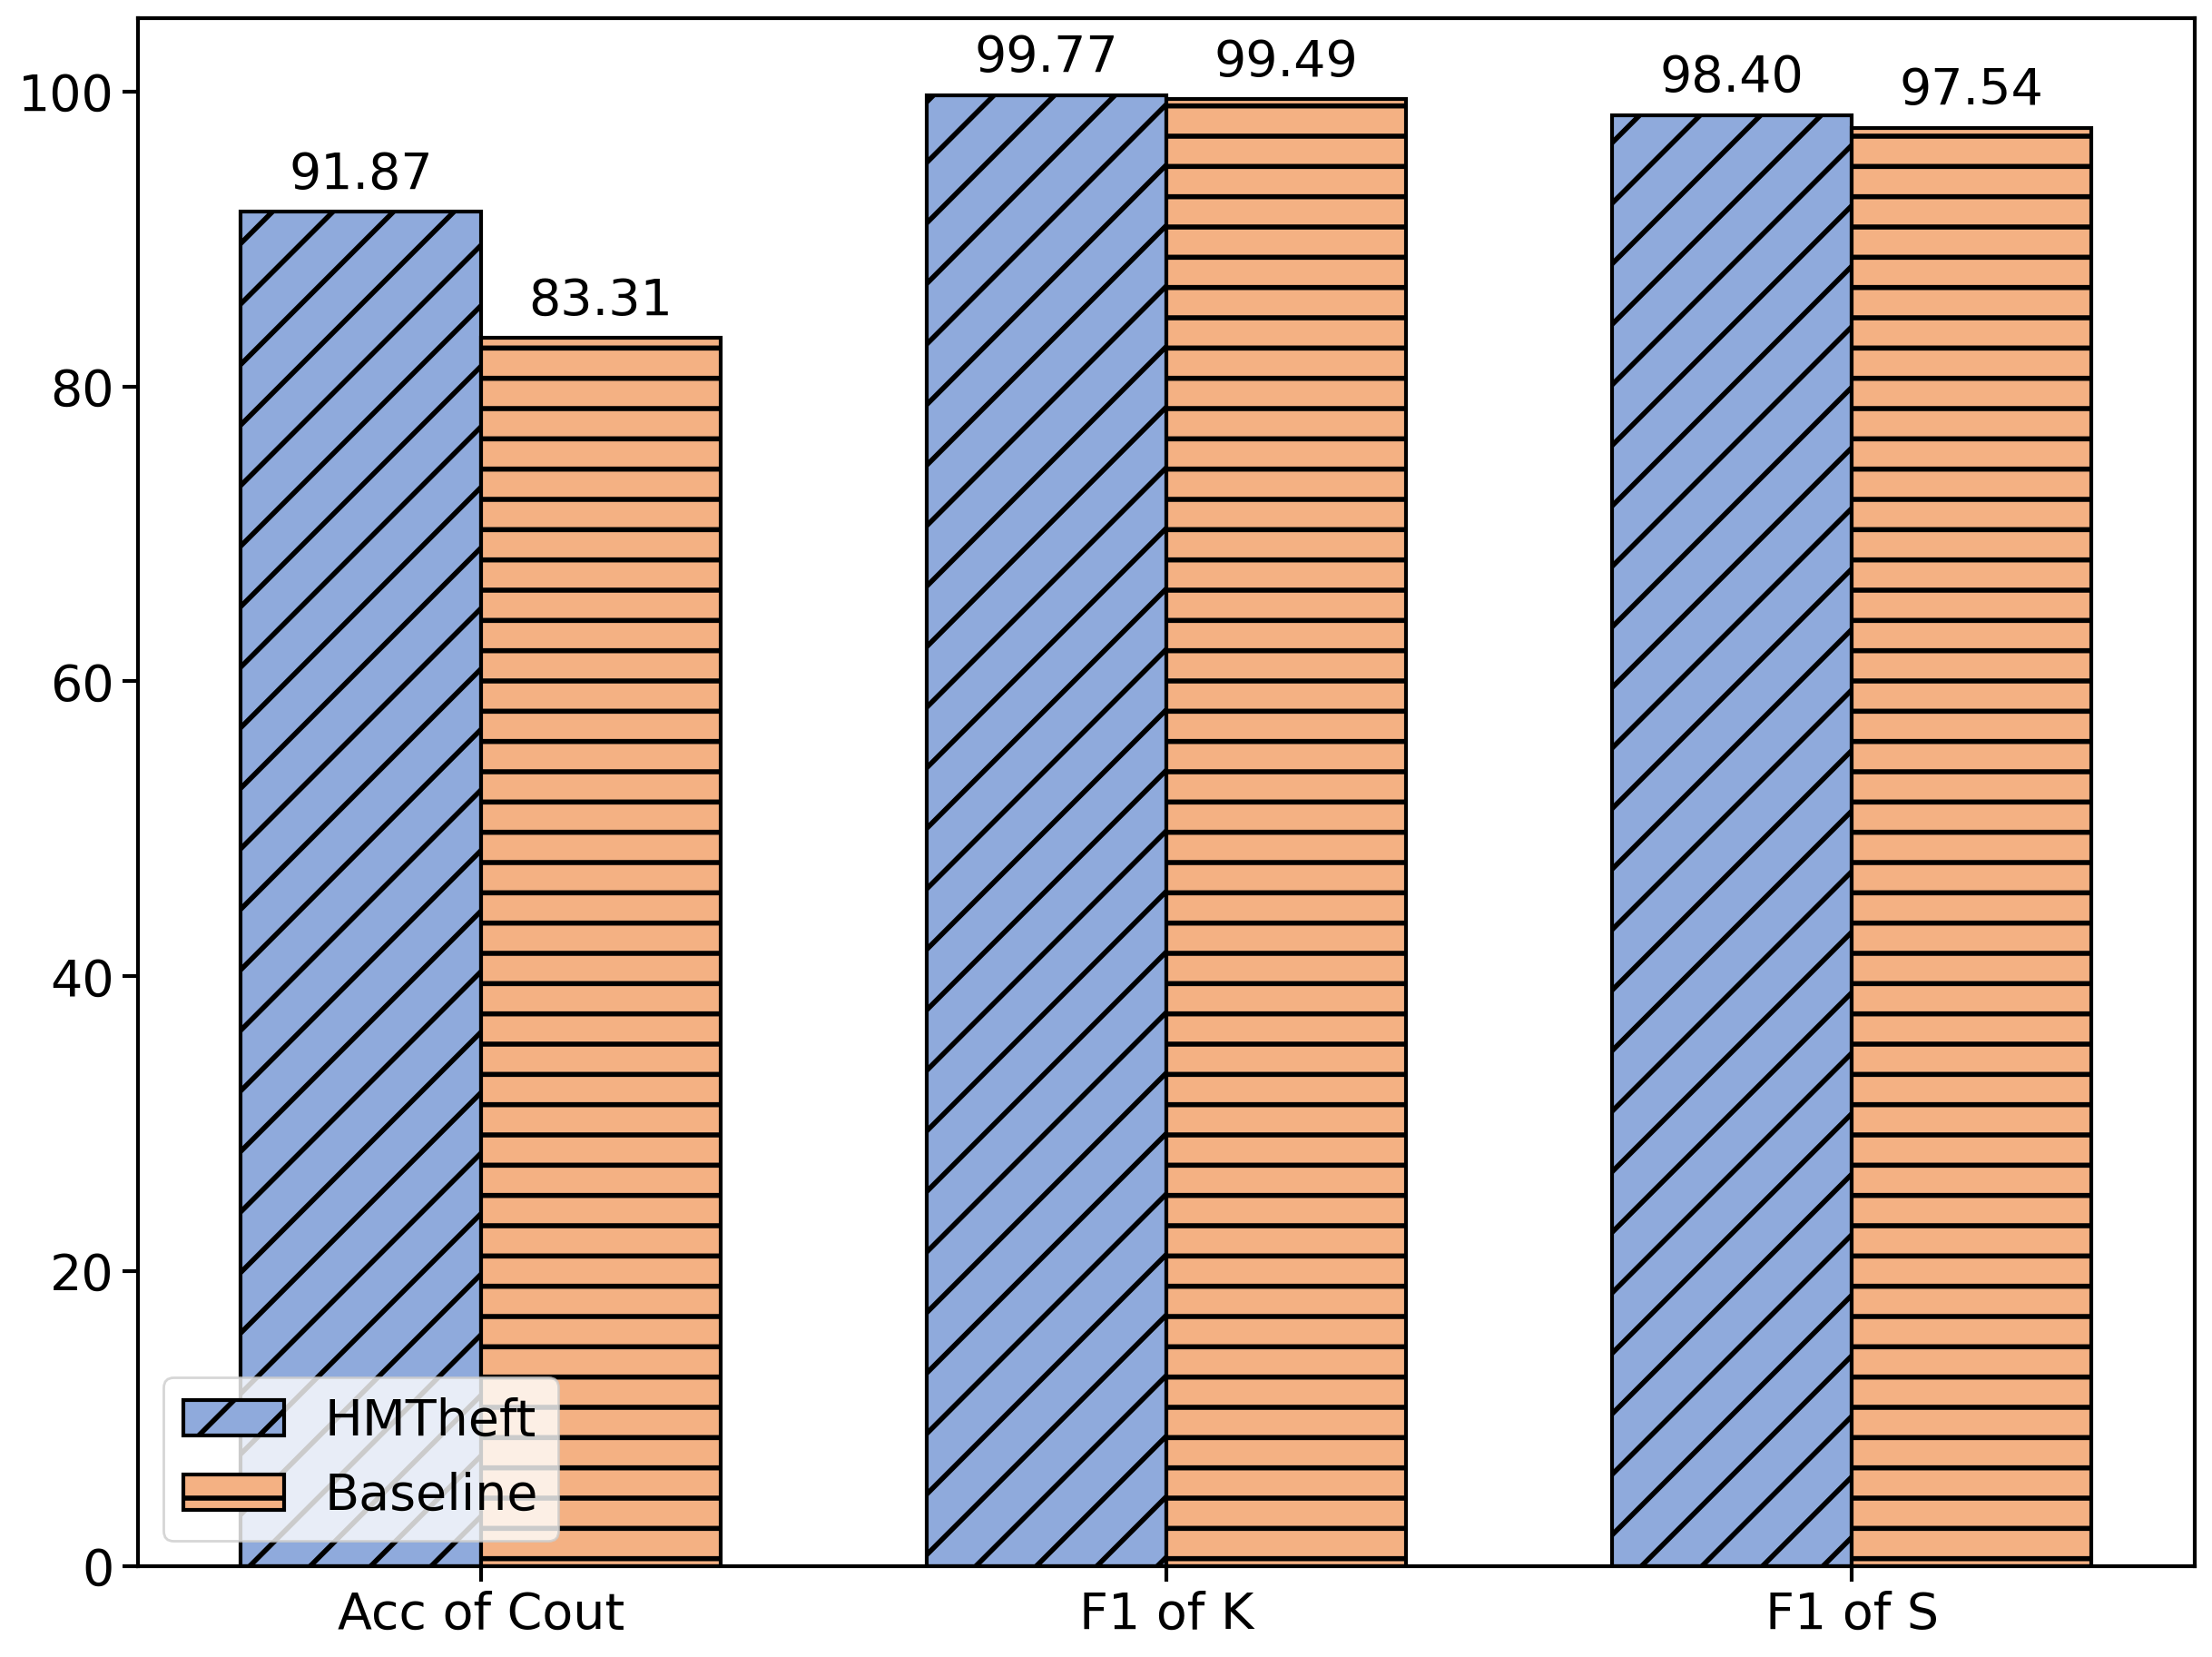

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Acc of Cout", "F1 of K", "F1 of S"]
hmtheft = [91.87, 99.77, 98.40]
baseline = [83.31, 99.49, 97.54]

x_positions = np.arange(len(metrics))
bar_width = 0.35

plt.rcParams["hatch.linewidth"] = 2.0
fig, ax = plt.subplots(figsize=(12.8, 9.6), dpi=200)
hmtheft_bars = ax.bar(
    x_positions - bar_width / 2,
    hmtheft,
    bar_width,
    label="HMTheft",
    color="#8FAADC",
    edgecolor="black",
    linewidth=1.5,
    hatch="/",
)
baseline_bars = ax.bar(
    x_positions + bar_width / 2,
    baseline,
    bar_width,
    label="Baseline",
    color="#F4B183",
    edgecolor="black",
    linewidth=1.5,
    hatch="-",
)

ax.set_xticks(x_positions, metrics)
ax.set_xlim(-0.5, 2.5)
ax.set_ylim(0, 105)
ax.set_yticks(np.arange(0, 101, 20))
ax.tick_params(axis="both", labelsize=20, width=1.5, length=6)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

ax.legend(loc="lower left", fontsize=20, framealpha=0.8)
ax.bar_label(hmtheft_bars, fmt="%.2f", padding=5, fontsize=20)
ax.bar_label(baseline_bars, fmt="%.2f", padding=5, fontsize=20)

fig.subplots_adjust(left=0.08, right=0.965, bottom=0.08, top=0.968)
output_dir = Path("plot")
output_dir.mkdir(exist_ok=True)
fig.savefig(output_dir / "figure7_reproduced.png", dpi=200)
fig.savefig(output_dir / "figure7_reproduced.eps", format="eps")
plt.show()